# Extended-Kagome tight-binding model

This notebook builds the 14-site primitive cell represented by the supplied hexagonal sketch. The colors and text labels in the sketch are ignored: every site has the same on-site energy (set to zero).

Hopping shells are ordered by the **physical Euclidean separation in the infinite periodic lattice**, including translated neighboring cells. This removes an ambiguity in an isolated-cell drawing: some short bonds cross a primitive-cell boundary. The first four distance shells preserve the alternating compact localized state. The first shell that breaks its destructive-interference condition is the fifth Euclidean shell,

$$d_5=\sqrt{4+\sqrt3}\,\ell\simeq2.39417\ell.$$

It is therefore called $t_5$ below. Calling it $t_4$ would skip the shorter, purely intra-cell $d_4=2\ell$ shell. The calculation explicitly counts intra- and inter-cell bonds in every shell and tests the compact-state residual.


In [15]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

np.set_printoptions(precision=6, suppress=True)


## Geometry

Let $\ell$ be the nearest-neighbor distance. The triangular Bravais vectors are

$$\mathbf a_1=A(1,0),\qquad \mathbf a_2=A(1/2,\sqrt3/2),\qquad A=(3+\sqrt3)\ell.$$

The basis contains six central-hexagon sites, six surrounding sites, and two inequivalent boundary sites. Translated copies of the two boundary sites generate all six corner sites drawn in the hexagonal Wigner-Seitz cell.


In [16]:
ell = 1.0
sqrt3 = np.sqrt(3.0)
A = (3.0 + sqrt3) * ell

a1 = np.array([A, 0.0])
a2 = np.array([A / 2.0, sqrt3 * A / 2.0])
lattice_vectors = np.stack([a1, a2])

central_sites = np.array([
    ell * np.array([np.cos(j * np.pi / 3), np.sin(j * np.pi / 3)])
    for j in range(6)
])
surrounding_sites = np.array([
    sqrt3 * ell * np.array([
        np.cos(j * np.pi / 3 + np.pi / 6),
        np.sin(j * np.pi / 3 + np.pi / 6),
    ])
    for j in range(6)
])
boundary_sites = np.array([
    [A / 2.0, A / (2.0 * sqrt3)],
    [0.0, A / sqrt3],
])
basis_positions = np.vstack([central_sites, surrounding_sites, boundary_sites])
site_names = [f'C{j}' for j in range(6)] + [f'S{j}' for j in range(6)] + ['B0', 'B1']
number_of_sites = len(basis_positions)
assert number_of_sites == 14


In [17]:
# Enumerate physical-distance shells in the infinite periodic lattice.
# A record (alpha, beta, n1, n2, displacement) joins alpha in the home
# cell to beta in cell n1*a1+n2*a2. Both directed orientations are kept;
# this makes the Bloch sum and Hermiticity explicit.
distance_tolerance = 1e-9 * ell
shell_distances = np.array([
    1.0,
    sqrt3,
    np.sqrt(2.0 + sqrt3),
    2.0,
    np.sqrt(4.0 + sqrt3),
]) * ell

shell_records = []
for shell_distance in shell_distances:
    records = []
    for alpha, r_alpha in enumerate(basis_positions):
        for beta, r_beta in enumerate(basis_positions):
            for n1 in (-1, 0, 1):
                for n2 in (-1, 0, 1):
                    if alpha == beta and n1 == 0 and n2 == 0:
                        continue
                    displacement = r_beta + n1 * a1 + n2 * a2 - r_alpha
                    if np.isclose(
                        np.linalg.norm(displacement), shell_distance,
                        atol=distance_tolerance, rtol=0.0,
                    ):
                        records.append((alpha, beta, n1, n2, displacement))
    shell_records.append(records)

shell_bond_counts = []
for shell_index, (shell_distance, records) in enumerate(
    zip(shell_distances, shell_records), start=1
):
    total_bonds = len(records) // 2
    intercell_bonds = sum(
        (n1 != 0 or n2 != 0) for _, _, n1, n2, _ in records
    ) // 2
    intracell_bonds = total_bonds - intercell_bonds
    shell_bond_counts.append((total_bonds, intracell_bonds, intercell_bonds))
    print(
        f't{shell_index}: d/ell={shell_distance / ell:.9f}; '
        f'{total_bonds} bonds/cell = {intracell_bonds} intra + '
        f'{intercell_bonds} inter'
    )

assert shell_bond_counts == [
    (24, 20, 4), (18, 12, 6), (12, 4, 8), (15, 15, 0), (24, 4, 20)
]


t1: d/ell=1.000000000; 24 bonds/cell = 20 intra + 4 inter
t2: d/ell=1.732050808; 18 bonds/cell = 12 intra + 6 inter
t3: d/ell=1.931851653; 12 bonds/cell = 4 intra + 8 inter
t4: d/ell=2.000000000; 15 bonds/cell = 15 intra + 0 inter
t5: d/ell=2.394170171; 24 bonds/cell = 4 intra + 20 inter


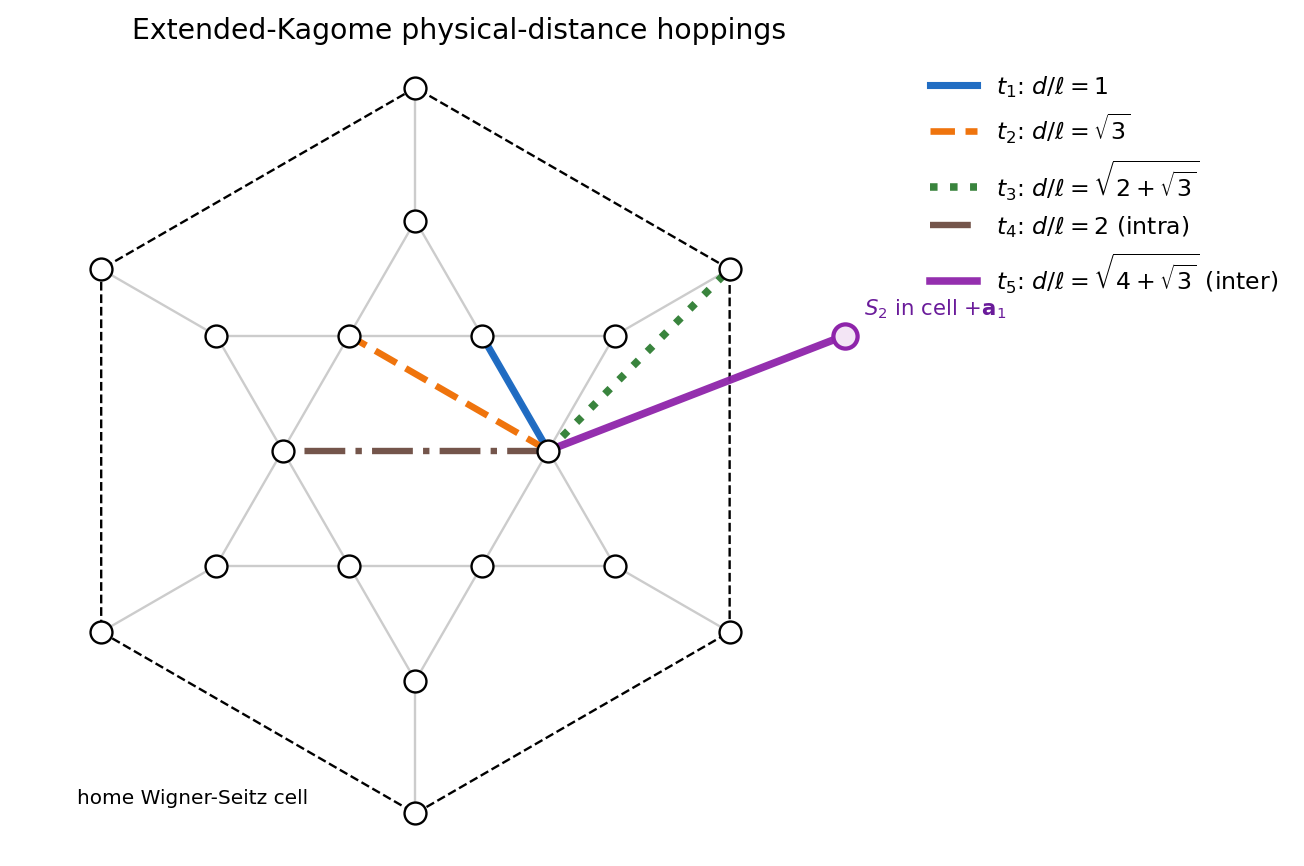

In [18]:
# Geometry check. t1--t4 examples lie in the displayed home cell;
# the highlighted t5 example explicitly ends in cell +a1.
fig, ax = plt.subplots(figsize=(7.4, 5.2), dpi=170)

display_boundary = np.array([
    boundary_sites[0], boundary_sites[1], boundary_sites[0] - a1,
    boundary_sites[1] - a2, boundary_sites[0] - a2,
    boundary_sites[1] + a1 - a2,
])
display_positions = np.vstack([central_sites, surrounding_sites, display_boundary])

# Draw the home-cell nearest-neighbor skeleton in light gray.
for first_site in range(len(display_positions)):
    for second_site in range(first_site + 1, len(display_positions)):
        start = display_positions[first_site]
        stop = display_positions[second_site]
        if np.isclose(
            np.linalg.norm(stop - start), ell,
            atol=distance_tolerance, rtol=0.0,
        ):
            ax.plot(
                [start[0], stop[0]], [start[1], stop[1]],
                color='0.80', linewidth=1.0, zorder=0,
            )

representative_hoppings = [
    (0, 1, 0, 0),   # t1: C0 -> C1
    (0, 2, 0, 0),   # t2: C0 -> C2
    (0, 12, 0, 0),  # t3: C0 -> B0
    (0, 3, 0, 0),   # t4: C0 -> C3
    (0, 8, 1, 0),   # t5: C0 -> S2 in cell +a1
]
hopping_styles = [
    (rf'$t_1$: $d/\ell=1$', '#1565c0', '-', 3.0),
    (rf'$t_2$: $d/\ell=\sqrt{{3}}$', '#ef6c00', '--', 2.8),
    (rf'$t_3$: $d/\ell=\sqrt{{2+\sqrt{{3}}}}$', '#2e7d32', ':', 3.2),
    (rf'$t_4$: $d/\ell=2$ (intra)', '#6d4c41', '-.', 2.7),
    (rf'$t_5$: $d/\ell=\sqrt{{4+\sqrt{{3}}}}$ (inter)', '#8e24aa', '-', 3.2),
]

for shell_index, (bond, style) in enumerate(
    zip(representative_hoppings, hopping_styles), start=1
):
    alpha, beta, n1, n2 = bond
    matching_records = [
        record for record in shell_records[shell_index - 1]
        if record[:4] == bond
    ]
    assert len(matching_records) == 1
    start = basis_positions[alpha]
    stop = start + matching_records[0][4]
    label, color, linestyle, linewidth = style
    ax.plot(
        [start[0], stop[0]], [start[1], stop[1]],
        color=color, linestyle=linestyle, linewidth=linewidth,
        alpha=0.95, zorder=2, label=label,
    )

ax.scatter(
    display_positions[:, 0], display_positions[:, 1],
    s=86, facecolor='white', edgecolor='black', zorder=3,
)

# Show the translated endpoint of the representative t5 bond.
translated_t5_site = basis_positions[8] + a1
ax.scatter(
    *translated_t5_site, s=105, facecolor='#f3e5f5',
    edgecolor='#8e24aa', linewidth=1.8, zorder=4,
)
ax.annotate(
    r'$S_2$ in cell $+\mathbf{a}_1$', translated_t5_site,
    xytext=(8, 9), textcoords='offset points', color='#6a1b9a', fontsize=9,
)

hexagon = np.array([
    (A / sqrt3) * np.array([
        np.cos(np.pi / 6 + j * np.pi / 3),
        np.sin(np.pi / 6 + j * np.pi / 3),
    ])
    for j in range(6)
])
ax.add_patch(Polygon(
    hexagon, closed=True, fill=False, ls='--', lw=1.0, color='black'
))
ax.text(-2.55, -2.65, 'home Wigner-Seitz cell', fontsize=8.5)
ax.set_xlim(-3.0, 3.65)
ax.set_ylim(-3.0, 3.0)
ax.set_aspect('equal')
ax.set_axis_off()
ax.set_title('Extended-Kagome physical-distance hoppings')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False)
fig.tight_layout()
plt.show()


## Periodic Bloch Hamiltonian

With zero on-site energy and physical-distance shells,

$$\hat H=-\sum_{m=1}^{5}t_m\sum_{\langle i,j\rangle_m}(c_i^\dagger c_j+\mathrm{h.c.}).$$

In the physical-position Bloch convention,

$$H_{\alpha\beta}(\mathbf k)=-\sum_{m=1}^{5}t_m\sum_{(n_1,n_2)\in\mathcal S_m^{\alpha\beta}}\exp\!\left[i\mathbf k\cdot(n_1\mathbf a_1+n_2\mathbf a_2+\mathbf r_\beta-\mathbf r_\alpha)\right].$$

The sets $\mathcal S_m^{\alpha\beta}$ are generated from translated copies of the 14-site basis, rather than from an isolated-cell drawing. Consequently, all shorter inter-cell bonds are included automatically in $t_1$, $t_2$, and $t_3$.


In [19]:
# Example hoppings in units of t1. The shorter d4 shell is retained;
# the small t5 term is the first physical-distance shell that disperses
# the compact-state-derived band.
t1 = 1.0
t2 = 1.0 * t1
t3 = 1.0 * t1
t4 = 1.0 * t1
t5 = 0.02 * t1
hoppings = np.array([t1, t2, t3, t4, t5])

POINTS_PER_SEGMENT = 220
SAVE_FIGURE = False
OUTPUT_FILE = Path('../../../output/testing_codes/extended_kagome_tight_binding.pdf')

def bloch_hamiltonian(k_vector, hopping_values=hoppings):
    hamiltonian = np.zeros((number_of_sites, number_of_sites), dtype=complex)
    for hopping, records in zip(hopping_values, shell_records):
        for alpha, beta, n1, n2, displacement in records:
            hamiltonian[alpha, beta] += -hopping * np.exp(
                1j * np.dot(k_vector, displacement)
            )
    return hamiltonian

b1 = np.array([2.0 * np.pi / A, -2.0 * np.pi / (sqrt3 * A)])
b2 = np.array([0.0, 4.0 * np.pi / (sqrt3 * A)])
Gamma = np.array([0.0, 0.0])
K = (2.0 * b1 + b2) / 3.0
M = (b1 + b2) / 2.0
k_nodes = [Gamma, K, M, Gamma]
k_labels = [r'$\Gamma$', 'K', 'M', r'$\Gamma$']

k_path = []
path_coordinate = []
node_coordinates = [0.0]
distance_so_far = 0.0
for segment_index, (start, stop) in enumerate(zip(k_nodes[:-1], k_nodes[1:])):
    segment = np.linspace(start, stop, POINTS_PER_SEGMENT, endpoint=True)
    if segment_index:
        segment = segment[1:]
    for point in segment:
        if k_path:
            distance_so_far += np.linalg.norm(point - k_path[-1])
        k_path.append(point)
        path_coordinate.append(distance_so_far)
    node_coordinates.append(distance_so_far)

k_path = np.asarray(k_path)
path_coordinate = np.asarray(path_coordinate)
eigensystems = [np.linalg.eigh(bloch_hamiltonian(k)) for k in k_path]
bands = np.stack([eigenvalues for eigenvalues, eigenvectors in eigensystems])
band_eigenvectors = np.stack([eigenvectors for eigenvalues, eigenvectors in eigensystems])

hermiticity_error = max(
    np.max(np.abs(bloch_hamiltonian(k) - bloch_hamiltonian(k).conj().T))
    for k in k_path[::50]
)
assert hermiticity_error < 1e-12


## Compact state and the first dispersive physical shell

Put alternating amplitudes $\psi_j=(-1)^j/\sqrt6$ on the six central sites and zero amplitude elsewhere. Acting on this vector, the first four complete physical-distance shells give

$$E_{\mathrm{flat}}^{(t_1-t_4)}=2t_1-2t_2+t_4.$$

The $t_3$ contribution vanishes, and leakage from the central hexagon cancels shell by shell through $d_4=2\ell$. The fourth shell is entirely intra-cell, so it changes only the constant band energy.

The fifth shell contains central-to-surrounding bonds across neighboring cells. Their phases do not cancel for general $\mathbf k$, so $H_5(\mathbf k)|\psi_{\mathrm{CLS}}\rangle$ has a component orthogonal to the compact state. The code below evaluates this residual for every shell and tracks the resulting band by maximum compact-state overlap.


In [20]:
reference_flat_energy = 2.0 * t1 - 2.0 * t2 + t4

def compact_bloch_state(k_vector):
    state = np.zeros(number_of_sites, dtype=complex)
    state[:6] = (
        (-1.0) ** np.arange(6)
        * np.exp(-1j * (central_sites @ k_vector))
        / np.sqrt(6.0)
    )
    return state

# Shell-by-shell cancellation audit. A zero leakage means that the
# complete symmetry-related shell preserves the compact eigenstate.
audit_fractions = np.linspace(0.0, 1.0, 24, endpoint=False)
audit_k_points = np.array([
    fraction_1 * b1 + fraction_2 * b2
    for fraction_1 in audit_fractions for fraction_2 in audit_fractions
])
shell_maximum_leakages = []
for audited_shell in range(5):
    unit_hoppings = np.zeros(5)
    unit_hoppings[audited_shell] = 1.0
    maximum_leakage = 0.0
    for k_vector in audit_k_points:
        compact_state = compact_bloch_state(k_vector)
        action = bloch_hamiltonian(k_vector, unit_hoppings) @ compact_state
        projected_energy = np.vdot(compact_state, action)
        leakage = np.linalg.norm(action - projected_energy * compact_state)
        maximum_leakage = max(maximum_leakage, leakage)
    shell_maximum_leakages.append(maximum_leakage)

print('Physical-distance shell audit:')
print('shell  d/ell        intra  inter  max orthogonal CLS leakage')
for shell_index, (distance, counts, leakage) in enumerate(
    zip(shell_distances, shell_bond_counts, shell_maximum_leakages), start=1
):
    total, intracell, intercell = counts
    print(
        f't{shell_index:<2d}   {distance / ell:11.9f}  '
        f'{intracell:5d}  {intercell:5d}  {leakage:.9e}'
    )

reference_hoppings = np.array([t1, t2, t3, t4, 0.0])
compact_state_residuals = np.array([
    np.linalg.norm(
        bloch_hamiltonian(k, reference_hoppings) @ compact_bloch_state(k)
        - reference_flat_energy * compact_bloch_state(k)
    )
    for k in k_path
])

flat_band_indices = []
flat_band_overlaps = []
for k_vector, eigenvectors in zip(k_path, band_eigenvectors):
    compact_state = compact_bloch_state(k_vector)
    overlaps = np.abs(eigenvectors.conj().T @ compact_state) ** 2
    flat_band_index = int(np.argmax(overlaps))
    flat_band_indices.append(flat_band_index)
    flat_band_overlaps.append(overlaps[flat_band_index])

flat_band_indices = np.asarray(flat_band_indices)
flat_band_overlaps = np.asarray(flat_band_overlaps)
flat_band_branch = bands[np.arange(len(k_path)), flat_band_indices]
flat_band_minimum = np.min(flat_band_branch)
flat_band_maximum = np.max(flat_band_branch)
flat_band_bandwidth = np.ptp(flat_band_branch)

def tracked_state_at(k_vector):
    eigenvalues, eigenvectors = np.linalg.eigh(bloch_hamiltonian(k_vector))
    overlaps = np.abs(eigenvectors.conj().T @ compact_bloch_state(k_vector)) ** 2
    index = int(np.argmax(overlaps))
    return eigenvalues[index], overlaps[index]

print(
    f'\nExample parameters: t1={t1:g}, t2={t2:g}, t3={t3:g}, '
    f't4={t4:g}, t5={t5:g}'
)
print(f'Four-shell flat-band reference: E_flat/t1 = {reference_flat_energy / t1:.9f}')
print(
    'Tracked t5-dispersed band range: '
    f'[{flat_band_minimum / t1:.9f}, {flat_band_maximum / t1:.9f}] t1'
)
print(f'Tracked bandwidth: {flat_band_bandwidth / t1:.9f} t1')
print(f'Minimum compact-state overlap: {flat_band_overlaps.min():.9f}')
print(f'Maximum four-shell CLS residual: {compact_state_residuals.max():.3e}')

print('\nTracked state at high-symmetry points:')
for label, k_point in zip(['Gamma', 'K', 'M'], [Gamma, K, M]):
    energy, overlap = tracked_state_at(k_point)
    print(f'{label:5s}: E/t1={energy / t1:.9f}, overlap={overlap:.9f}')


Physical-distance shell audit:
shell  d/ell        intra  inter  max orthogonal CLS leakage
t1    1.000000000     20      4  1.043075248e-15
t2    1.732050808     12      6  1.070412945e-15
t3    1.931851653      4      8  5.207407572e-16
t4    2.000000000     15      0  6.870994212e-16
t5    2.394170171      4     20  1.732050808e+00

Example parameters: t1=1, t2=1, t3=1, t4=1, t5=0.02
Four-shell flat-band reference: E_flat/t1 = 1.000000000
Tracked t5-dispersed band range: [0.998124304, 1.000000000] t1
Tracked bandwidth: 0.001875696 t1
Minimum compact-state overlap: 0.994851469
Maximum four-shell CLS residual: 7.308e-16

Tracked state at high-symmetry points:
Gamma: E/t1=1.000000000, overlap=1.000000000
K    : E/t1=0.998133038, overlap=0.995833943
M    : E/t1=1.000000000, overlap=0.999639786


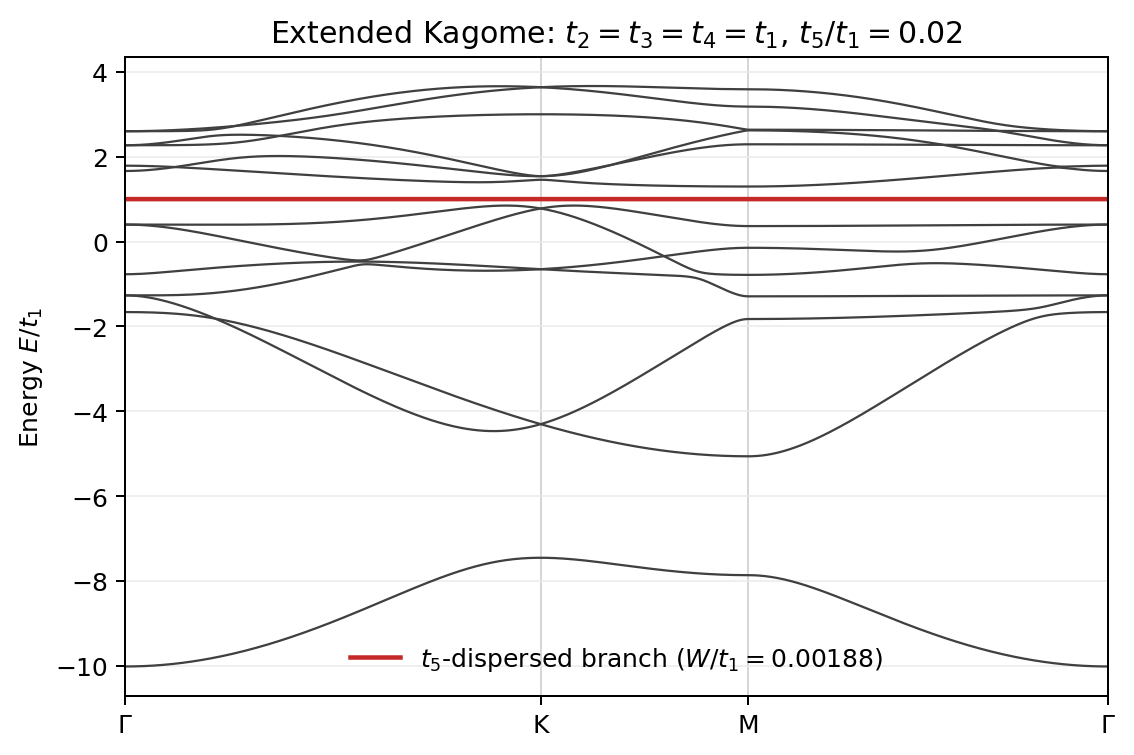

In [21]:
fig, ax = plt.subplots(figsize=(6.4, 4.3), dpi=180)

for band_index in range(number_of_sites):
    ax.plot(path_coordinate, bands[:, band_index] / t1, color='0.25', lw=0.9)
ax.plot(
    path_coordinate, flat_band_branch / t1, color='#c62828', lw=1.8,
    label=rf'$t_5$-dispersed branch ($W/t_1={flat_band_bandwidth / t1:.5f}$)',
)

for coordinate in node_coordinates:
    ax.axvline(coordinate, color='0.82', lw=0.7, zorder=0)
ax.set_xlim(node_coordinates[0], node_coordinates[-1])
ax.set_xticks(node_coordinates, k_labels)
ax.set_ylabel(r'Energy $E/t_1$')
ax.set_title(
    rf'Extended Kagome: $t_2=t_3=t_4=t_1$, $t_5/t_1={t5/t1:.2f}$'
)
ax.legend(frameon=False, loc='best')
ax.grid(axis='y', color='0.92', lw=0.6)
fig.tight_layout()

if SAVE_FIGURE:
    OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_FILE, bbox_inches='tight')

plt.show()


### Interpretation

The numerical shell audit is the check behind the distance claim: all translated-cell bonds in each shell are included. Shells $t_1$--$t_4$ have zero orthogonal compact-state leakage to numerical precision, whereas $t_5$ has nonzero leakage. The full diagonalization then confirms that the compact-state-derived eigenvalue acquires a finite bandwidth.

This conclusion assumes one symmetry-related hopping amplitude for every bond at the same physical distance. If intra- and inter-cell bonds at the same distance are assigned different amplitudes, that extra symmetry breaking can disperse the band already at a shorter distance; such a model is no longer parameterized by distance-only $t_1,t_2,\ldots$ shells.


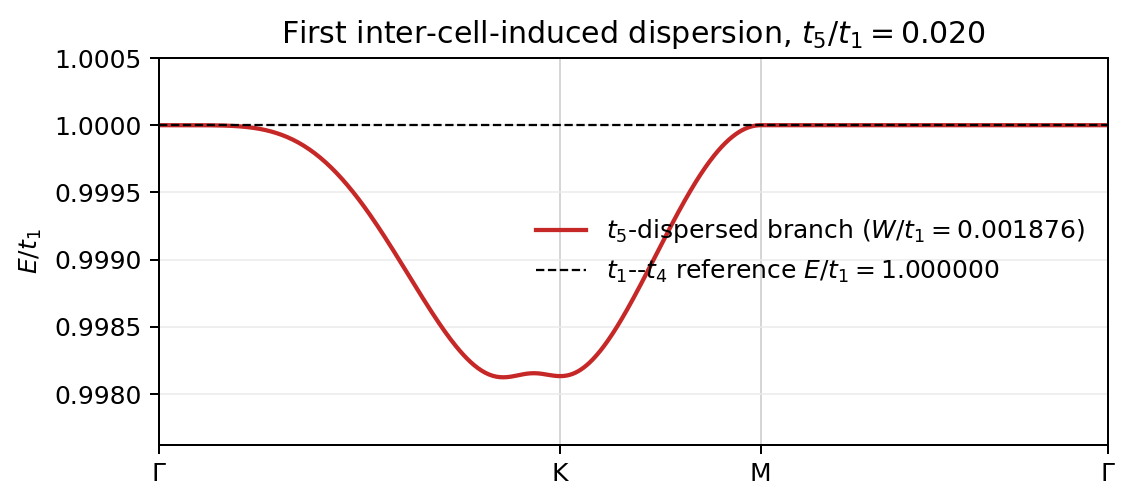

In [22]:
# Zoomed view of the compact-state-derived dispersive branch.
flat_band_branch_normalized = flat_band_branch / t1
reference_flat_energy_normalized = reference_flat_energy / t1
zoom_minimum = min(flat_band_branch_normalized.min(), reference_flat_energy_normalized)
zoom_maximum = max(flat_band_branch_normalized.max(), reference_flat_energy_normalized)
zoom_margin = max(0.0005, 0.18 * (zoom_maximum - zoom_minimum))

zoom_fig, zoom_ax = plt.subplots(figsize=(6.4, 2.9), dpi=180)
zoom_ax.plot(
    path_coordinate, flat_band_branch_normalized, color='#c62828', lw=1.7,
    label=rf'$t_5$-dispersed branch ($W/t_1={flat_band_bandwidth / t1:.6f}$)',
)
zoom_ax.axhline(
    reference_flat_energy_normalized, color='black', ls='--', lw=0.9,
    label=rf'$t_1$--$t_4$ reference $E/t_1={reference_flat_energy_normalized:.6f}$',
)
for coordinate in node_coordinates:
    zoom_ax.axvline(coordinate, color='0.82', lw=0.7, zorder=0)
zoom_ax.set_xlim(node_coordinates[0], node_coordinates[-1])
zoom_ax.set_ylim(zoom_minimum - zoom_margin, zoom_maximum + zoom_margin)
zoom_ax.set_xticks(node_coordinates, k_labels)
zoom_ax.set_ylabel(r'$E/t_1$')
zoom_ax.set_title(rf'First inter-cell-induced dispersion, $t_5/t_1={t5/t1:.3f}$')
zoom_ax.grid(axis='y', color='0.92', lw=0.6)
zoom_ax.legend(frameon=False, loc='best')
zoom_fig.tight_layout()
plt.show()


## Graph-distance hopping analysis

This section keeps the physical-distance results above unchanged and asks a separate question: group two orbitals by the minimum number of nearest-neighbor edges connecting them on the **infinite periodic graph**, including paths and endpoints in translated cells.

To distinguish this convention from the physical-distance hoppings $t_m$, let $g_m$ couple every pair whose shortest NN path has exactly $m$ edges. A graph shell generally mixes several Euclidean distances. We construct the periodic NN adjacency from all $d=\ell$ bonds and use breadth-first search from every basis orbital through graph distance four.


In [23]:
from collections import deque

maximum_graph_shell = 4

# Every NN edge includes its cell translation. BFS therefore explores
# the infinite periodic graph rather than the isolated 14-site drawing.
nearest_neighbor_adjacency = {site: [] for site in range(number_of_sites)}
for alpha, beta, n1, n2, displacement in shell_records[0]:
    nearest_neighbor_adjacency[alpha].append((beta, n1, n2))

graph_shell_records = [[] for _ in range(maximum_graph_shell)]
for alpha in range(number_of_sites):
    graph_distance = {(alpha, 0, 0): 0}
    queue = deque([(alpha, 0, 0)])
    while queue:
        site, cell_n1, cell_n2 = queue.popleft()
        distance = graph_distance[(site, cell_n1, cell_n2)]
        if distance == maximum_graph_shell:
            continue
        for beta, step_n1, step_n2 in nearest_neighbor_adjacency[site]:
            target = (beta, cell_n1 + step_n1, cell_n2 + step_n2)
            if target not in graph_distance:
                graph_distance[target] = distance + 1
                queue.append(target)

    for (beta, n1, n2), distance in graph_distance.items():
        if 1 <= distance <= maximum_graph_shell:
            displacement = (
                basis_positions[beta] + n1 * a1 + n2 * a2
                - basis_positions[alpha]
            )
            graph_shell_records[distance - 1].append(
                (alpha, beta, n1, n2, displacement)
            )

graph_shell_bond_counts = []
graph_shell_euclidean_distances = []
for graph_shell, records in enumerate(graph_shell_records, start=1):
    total_bonds = len(records) // 2
    intercell_bonds = sum(
        (n1 != 0 or n2 != 0) for _, _, n1, n2, _ in records
    ) // 2
    intracell_bonds = total_bonds - intercell_bonds
    euclidean_distances = sorted({
        round(np.linalg.norm(record[4]) / ell, 9) for record in records
    })
    graph_shell_bond_counts.append(
        (total_bonds, intracell_bonds, intercell_bonds)
    )
    graph_shell_euclidean_distances.append(euclidean_distances)
    print(
        f'g{graph_shell}: {total_bonds} bonds/cell = '
        f'{intracell_bonds} intra + {intercell_bonds} inter; '
        f'd/ell = {euclidean_distances}'
    )

assert graph_shell_bond_counts == [
    (24, 20, 4), (42, 28, 14), (69, 29, 40), (93, 12, 81)
]


g1: 24 bonds/cell = 20 intra + 4 inter; d/ell = [np.float64(1.0)]
g2: 42 bonds/cell = 28 intra + 14 inter; d/ell = [np.float64(1.732050808), np.float64(1.931851653), np.float64(2.0)]
g3: 69 bonds/cell = 29 intra + 40 inter; d/ell = [np.float64(2.0), np.float64(2.394170171), np.float64(2.645751311), np.float64(2.732050808), np.float64(2.909312911), np.float64(3.0)]
g4: 93 bonds/cell = 12 intra + 81 inter; d/ell = [np.float64(2.449489743), np.float64(2.732050808), np.float64(3.234826366), np.float64(3.346065215), np.float64(3.464101615), np.float64(3.632650881), np.float64(3.732050808), np.float64(3.898224265)]


In [24]:
def graph_bloch_hamiltonian(k_vector, graph_hoppings):
    hamiltonian = np.zeros((number_of_sites, number_of_sites), dtype=complex)
    for hopping, records in zip(graph_hoppings, graph_shell_records):
        for alpha, beta, n1, n2, displacement in records:
            hamiltonian[alpha, beta] += -hopping * np.exp(
                1j * np.dot(k_vector, displacement)
            )
    return hamiltonian

graph_shell_maximum_leakages = []
graph_shell_projected_widths = []
graph_shell_projected_centers = []
for audited_shell in range(maximum_graph_shell):
    unit_graph_hoppings = np.zeros(maximum_graph_shell)
    unit_graph_hoppings[audited_shell] = 1.0
    leakages = []
    projected_energies = []
    for k_vector in audit_k_points:
        compact_state = compact_bloch_state(k_vector)
        action = (
            graph_bloch_hamiltonian(k_vector, unit_graph_hoppings)
            @ compact_state
        )
        projected_energy = np.vdot(compact_state, action).real
        projected_energies.append(projected_energy)
        leakages.append(
            np.linalg.norm(action - projected_energy * compact_state)
        )
    graph_shell_maximum_leakages.append(max(leakages))
    graph_shell_projected_widths.append(np.ptp(projected_energies))
    graph_shell_projected_centers.append(np.mean(projected_energies))

print('Graph-distance shell audit over the 2D Brillouin zone:')
print('shell  intra  inter  projected width  max orthogonal CLS leakage')
for graph_shell, (counts, width, leakage) in enumerate(zip(
    graph_shell_bond_counts,
    graph_shell_projected_widths,
    graph_shell_maximum_leakages,
), start=1):
    total, intracell, intercell = counts
    print(
        f'g{graph_shell:<2d}   {intracell:5d}  {intercell:5d}  '
        f'{width:15.9e}  {leakage:26.9e}'
    )

assert max(graph_shell_maximum_leakages[:3]) < 1e-12
assert max(graph_shell_projected_widths[:3]) < 1e-12
assert graph_shell_maximum_leakages[3] > 0.9
assert graph_shell_projected_widths[3] > 1.4


Graph-distance shell audit over the 2D Brillouin zone:
shell  intra  inter  projected width  max orthogonal CLS leakage
g1       20      4  8.881784197e-16             1.049001500e-15
g2       28     14  8.881784197e-16             1.150141288e-15
g3       29     40  4.440892099e-16             1.188962817e-15
g4       12     81  1.500000000e+00             1.000000000e+00


### Shortest dispersive graph shell

The alternating central-hexagon state obeys

$$
H^{(g)}_1|\psi_{\mathrm{CLS}}\rangle=2|\psi_{\mathrm{CLS}}\rangle,
\qquad
H^{(g)}_2|\psi_{\mathrm{CLS}}\rangle=-2|\psi_{\mathrm{CLS}}\rangle,
\qquad
H^{(g)}_3|\psi_{\mathrm{CLS}}\rangle=|\psi_{\mathrm{CLS}}\rangle.
$$

Hence hopping through graph shell three leaves an exact flat band at

$$
\boxed{E_{\mathrm{flat}}^{(g_1-g_3)}=2g_1-2g_2+g_3}.
$$

The fourth graph shell has both a momentum-dependent compact-state expectation value and a nonzero component orthogonal to the compact state. It is therefore the first graph-distance shell that produces dispersion:

$$
\boxed{d_{\mathrm{graph}}=4\ \text{nearest-neighbor steps}.}
$$

This conclusion includes all intra- and inter-cell pairs. Graph shell four contains 93 undirected bonds per primitive cell: 12 intra-cell and 81 inter-cell. It is not one Euclidean-distance shell; its members span several physical distances. Its physically shortest members have $d=\sqrt6\,\ell$ and are inter-cell surrounding-to-surrounding pairs, for example $S_0$ in the home cell to $S_3$ in cell $+\mathbf a_1$. The dispersion statement applies to the complete uniform-$g_4$ graph shell, not to that one Euclidean subset in isolation.


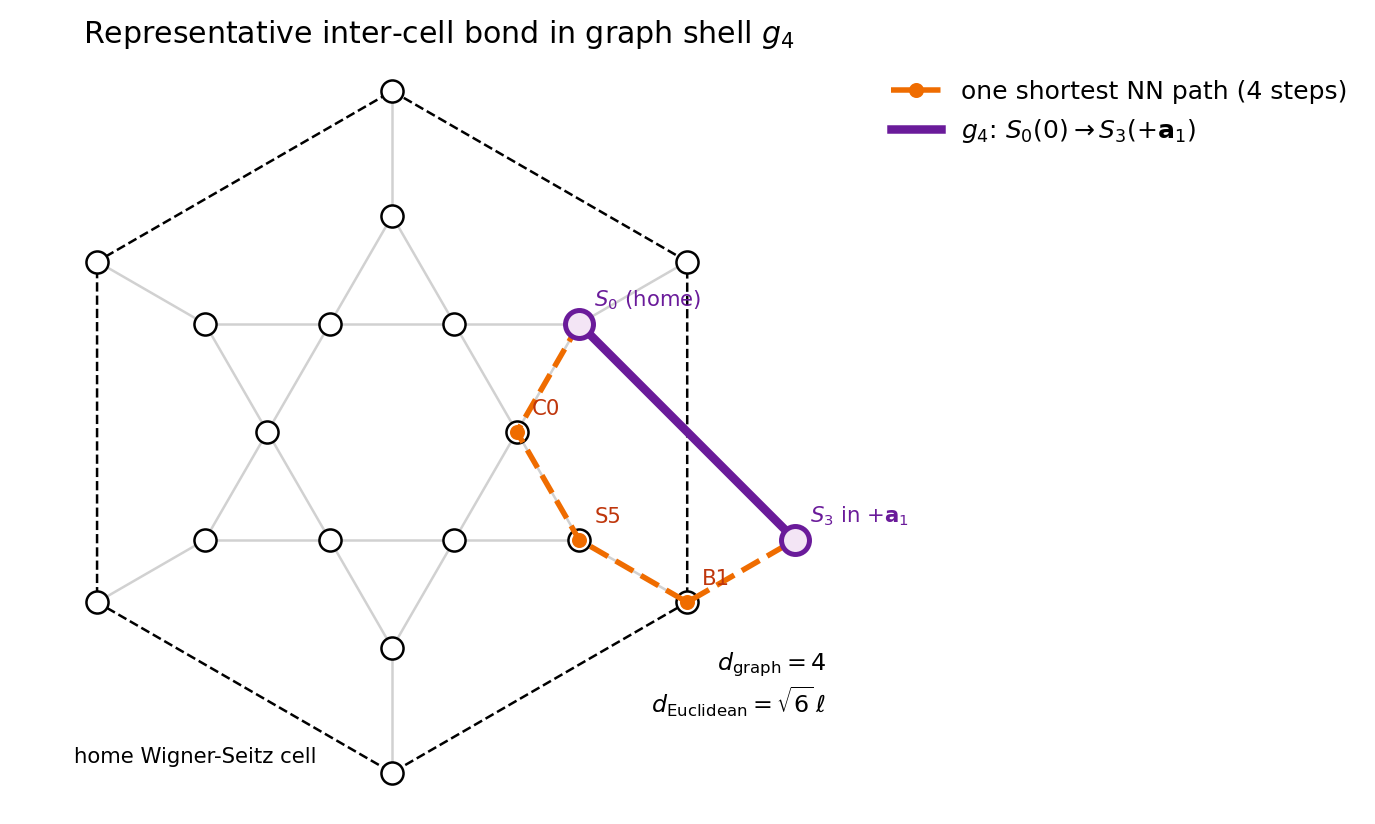

In [25]:
# Representative shortest-physical member of graph shell g4:
# S0 in the home cell -> S3 in cell +a1. The direct hopping has
# Euclidean length sqrt(6)*ell, while the shortest NN path has 4 steps.
graph_bond_start = (6, 0, 0)   # S0 in the home cell
graph_bond_stop = (9, 1, 0)    # S3 in cell +a1

# Recover one shortest path from the periodic NN adjacency.
graph_queue = deque([graph_bond_start])
graph_predecessor = {graph_bond_start: None}
while graph_queue:
    graph_node = graph_queue.popleft()
    if graph_node == graph_bond_stop:
        break
    site, cell_n1, cell_n2 = graph_node
    for beta, step_n1, step_n2 in nearest_neighbor_adjacency[site]:
        target = (
            beta, cell_n1 + step_n1, cell_n2 + step_n2
        )
        if target not in graph_predecessor:
            graph_predecessor[target] = graph_node
            graph_queue.append(target)

graph_path_nodes = []
graph_node = graph_bond_stop
while graph_node is not None:
    graph_path_nodes.append(graph_node)
    graph_node = graph_predecessor[graph_node]
graph_path_nodes = graph_path_nodes[::-1]
assert len(graph_path_nodes) - 1 == 4

def translated_position(node):
    site, cell_n1, cell_n2 = node
    return basis_positions[site] + cell_n1 * a1 + cell_n2 * a2

graph_path_positions = np.array([
    translated_position(node) for node in graph_path_nodes
])
graph_direct_start = graph_path_positions[0]
graph_direct_stop = graph_path_positions[-1]
assert np.isclose(
    np.linalg.norm(graph_direct_stop - graph_direct_start),
    np.sqrt(6.0) * ell,
    atol=distance_tolerance,
    rtol=0.0,
)

graph_geometry_fig, graph_geometry_ax = plt.subplots(
    figsize=(7.2, 5.2), dpi=180
)

# Existing home-cell NN skeleton and Wigner-Seitz boundary.
for first_site in range(len(display_positions)):
    for second_site in range(first_site + 1, len(display_positions)):
        start = display_positions[first_site]
        stop = display_positions[second_site]
        if np.isclose(
            np.linalg.norm(stop - start), ell,
            atol=distance_tolerance,
            rtol=0.0,
        ):
            graph_geometry_ax.plot(
                [start[0], stop[0]], [start[1], stop[1]],
                color='0.82', linewidth=1.0, zorder=0,
            )
graph_geometry_ax.scatter(
    display_positions[:, 0], display_positions[:, 1],
    s=78, facecolor='white', edgecolor='black', zorder=2,
)
graph_geometry_ax.add_patch(Polygon(
    hexagon, closed=True, fill=False, ls='--', lw=1.0, color='black'
))

# Four-step NN path and the direct graph-shell hopping between its endpoints.
graph_geometry_ax.plot(
    graph_path_positions[:, 0], graph_path_positions[:, 1],
    color='#ef6c00', linestyle='--', marker='o', markersize=5.0,
    linewidth=2.2, zorder=3,
    label='one shortest NN path (4 steps)',
)
graph_geometry_ax.plot(
    [graph_direct_start[0], graph_direct_stop[0]],
    [graph_direct_start[1], graph_direct_stop[1]],
    color='#6a1b9a', linewidth=3.4, zorder=4,
    label=rf'$g_4$: $S_0(0)\rightarrow S_3(+\mathbf{{a}}_1)$',
)
graph_geometry_ax.scatter(
    [graph_direct_start[0], graph_direct_stop[0]],
    [graph_direct_start[1], graph_direct_stop[1]],
    s=125, facecolor='#f3e5f5', edgecolor='#6a1b9a',
    linewidth=2.0, zorder=5,
)

for path_index, (node, position) in enumerate(zip(
    graph_path_nodes, graph_path_positions
)):
    site, cell_n1, cell_n2 = node
    if path_index == 0:
        label = r'$S_0$ (home)'
    elif path_index == len(graph_path_nodes) - 1:
        label = r'$S_3$ in $+\mathbf{a}_1$'
    else:
        label = site_names[site]
    graph_geometry_ax.annotate(
        label, position, xytext=(6, 7), textcoords='offset points',
        fontsize=8.5,
        color='#6a1b9a' if path_index in (0, 4) else '#bf360c',
    )

graph_geometry_ax.text(
    -2.55, -2.65, 'home Wigner-Seitz cell', fontsize=8.5
)
graph_geometry_ax.text(
    3.48, -1.75,
    r'$d_{\mathrm{graph}}=4$' + '\n' + r'$d_{\mathrm{Euclidean}}=\sqrt{6}\,\ell$',
    ha='right', va='top', fontsize=9.5,
)
graph_geometry_ax.set_xlim(-3.0, 3.75)
graph_geometry_ax.set_ylim(-3.0, 3.0)
graph_geometry_ax.set_aspect('equal')
graph_geometry_ax.set_axis_off()
graph_geometry_ax.set_title(
    r'Representative inter-cell bond in graph shell $g_4$'
)
graph_geometry_ax.legend(
    loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False
)
graph_geometry_fig.tight_layout()
plt.show()


In [26]:
# Example graph-distance hoppings. These g_m are independent of the
# physical-distance t_m used in the preceding section.
g1 = 1.0
g2 = 0.20 * g1
g3 = 0.20 * g1
g4 = 0.02 * g1
graph_hoppings = np.array([g1, g2, g3, g4])
graph_reference_energy = 2.0 * g1 - 2.0 * g2 + g3

graph_eigensystems = [
    np.linalg.eigh(graph_bloch_hamiltonian(k, graph_hoppings))
    for k in k_path
]
graph_bands = np.stack([
    eigenvalues for eigenvalues, eigenvectors in graph_eigensystems
])
graph_eigenvectors = np.stack([
    eigenvectors for eigenvalues, eigenvectors in graph_eigensystems
])

graph_flat_indices = []
graph_flat_overlaps = []
for k_vector, eigenvectors in zip(k_path, graph_eigenvectors):
    overlaps = np.abs(
        eigenvectors.conj().T @ compact_bloch_state(k_vector)
    ) ** 2
    index = int(np.argmax(overlaps))
    graph_flat_indices.append(index)
    graph_flat_overlaps.append(overlaps[index])

graph_flat_indices = np.asarray(graph_flat_indices)
graph_flat_overlaps = np.asarray(graph_flat_overlaps)
graph_flat_branch = graph_bands[
    np.arange(len(k_path)), graph_flat_indices
]
graph_flat_minimum = graph_flat_branch.min()
graph_flat_maximum = graph_flat_branch.max()
graph_flat_bandwidth = np.ptp(graph_flat_branch)

def graph_tracked_state_at(k_vector):
    eigenvalues, eigenvectors = np.linalg.eigh(
        graph_bloch_hamiltonian(k_vector, graph_hoppings)
    )
    overlaps = np.abs(
        eigenvectors.conj().T @ compact_bloch_state(k_vector)
    ) ** 2
    index = int(np.argmax(overlaps))
    return eigenvalues[index], overlaps[index]

print(
    f'Example graph hoppings: g1={g1:g}, g2={g2:g}, '
    f'g3={g3:g}, g4={g4:g}'
)
print(
    f'Three-graph-shell reference: E_flat/g1 = '
    f'{graph_reference_energy / g1:.9f}'
)
print(
    'Tracked g4-dispersed range: '
    f'[{graph_flat_minimum / g1:.9f}, '
    f'{graph_flat_maximum / g1:.9f}] g1'
)
print(f'Tracked bandwidth: {graph_flat_bandwidth / g1:.9f} g1')
print(
    f'Minimum compact-state overlap: '
    f'{graph_flat_overlaps.min():.9f}'
)
print('Tracked state at high-symmetry points:')
for label, k_point in zip(['Gamma', 'K', 'M'], [Gamma, K, M]):
    energy, overlap = graph_tracked_state_at(k_point)
    print(
        f'{label:5s}: E/g1={energy / g1:.9f}, '
        f'overlap={overlap:.9f}'
    )


Example graph hoppings: g1=1, g2=0.2, g3=0.2, g4=0.02
Three-graph-shell reference: E_flat/g1 = 1.800000000
Tracked g4-dispersed range: [1.780000000, 1.810150734] g1
Tracked bandwidth: 0.030150734 g1
Minimum compact-state overlap: 0.998180158
Tracked state at high-symmetry points:
Gamma: E/g1=1.780000000, overlap=1.000000000
K    : E/g1=1.810150734, overlap=0.999849198
M    : E/g1=1.806881456, overlap=0.999811719


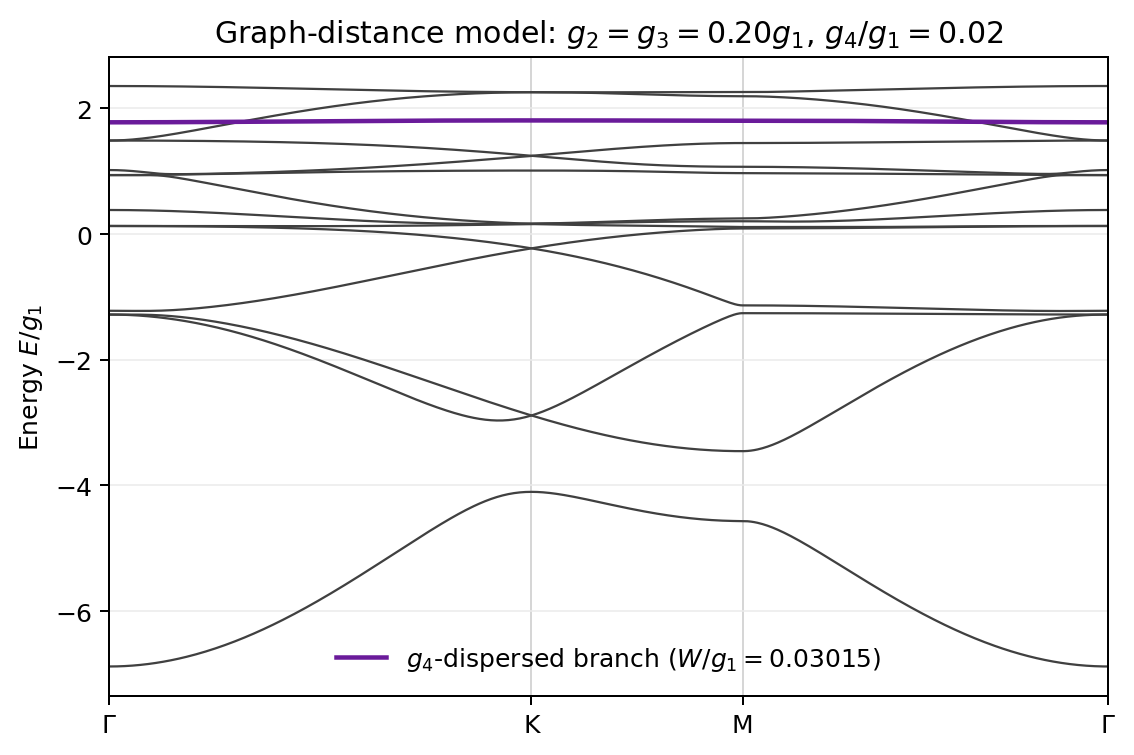

In [27]:
graph_fig, graph_ax = plt.subplots(figsize=(6.4, 4.3), dpi=180)

for band_index in range(number_of_sites):
    graph_ax.plot(
        path_coordinate, graph_bands[:, band_index] / g1,
        color='0.25', lw=0.9,
    )
graph_ax.plot(
    path_coordinate, graph_flat_branch / g1,
    color='#6a1b9a', lw=1.8,
    label=rf'$g_4$-dispersed branch '
          rf'($W/g_1={graph_flat_bandwidth / g1:.5f}$)',
)
for coordinate in node_coordinates:
    graph_ax.axvline(coordinate, color='0.82', lw=0.7, zorder=0)
graph_ax.set_xlim(node_coordinates[0], node_coordinates[-1])
graph_ax.set_xticks(node_coordinates, k_labels)
graph_ax.set_ylabel(r'Energy $E/g_1$')
graph_ax.set_title(
    rf'Graph-distance model: $g_2=g_3=0.20g_1$, '
    rf'$g_4/g_1={g4/g1:.2f}$'
)
graph_ax.grid(axis='y', color='0.92', lw=0.6)
graph_ax.legend(frameon=False, loc='best')
graph_fig.tight_layout()
plt.show()


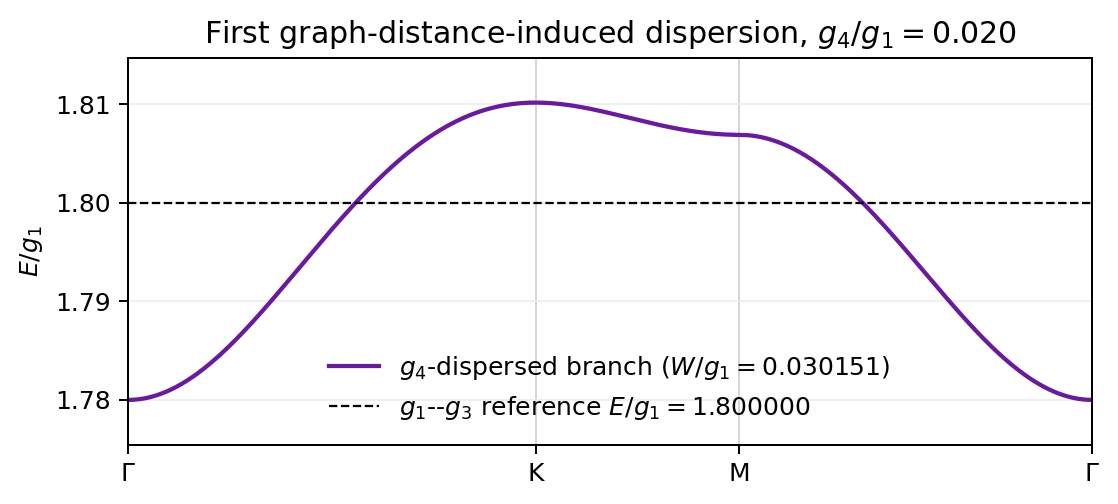

In [28]:
graph_branch_normalized = graph_flat_branch / g1
graph_reference_normalized = graph_reference_energy / g1
graph_zoom_minimum = min(
    graph_branch_normalized.min(), graph_reference_normalized
)
graph_zoom_maximum = max(
    graph_branch_normalized.max(), graph_reference_normalized
)
graph_zoom_margin = max(
    0.002, 0.15 * (graph_zoom_maximum - graph_zoom_minimum)
)

graph_zoom_fig, graph_zoom_ax = plt.subplots(
    figsize=(6.4, 2.9), dpi=180
)
graph_zoom_ax.plot(
    path_coordinate, graph_branch_normalized,
    color='#6a1b9a', lw=1.7,
    label=rf'$g_4$-dispersed branch '
          rf'($W/g_1={graph_flat_bandwidth / g1:.6f}$)',
)
graph_zoom_ax.axhline(
    graph_reference_normalized, color='black', ls='--', lw=0.9,
    label=rf'$g_1$--$g_3$ reference '
          rf'$E/g_1={graph_reference_normalized:.6f}$',
)
for coordinate in node_coordinates:
    graph_zoom_ax.axvline(
        coordinate, color='0.82', lw=0.7, zorder=0
    )
graph_zoom_ax.set_xlim(node_coordinates[0], node_coordinates[-1])
graph_zoom_ax.set_ylim(
    graph_zoom_minimum - graph_zoom_margin,
    graph_zoom_maximum + graph_zoom_margin,
)
graph_zoom_ax.set_xticks(node_coordinates, k_labels)
graph_zoom_ax.set_ylabel(r'$E/g_1$')
graph_zoom_ax.set_title(
    rf'First graph-distance-induced dispersion, $g_4/g_1={g4/g1:.3f}$'
)
graph_zoom_ax.grid(axis='y', color='0.92', lw=0.6)
graph_zoom_ax.legend(frameon=False, loc='best')
graph_zoom_fig.tight_layout()
plt.show()
